DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES

## Recurrent Neural Networks vs Transformers for Time Series Prediction


STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AE05975

Name: Bala Gangadhara Tilak

Email: 2025ae05975@wilp.bits-pilani.ac.in

Date: 20-04-2026

ASSIGNMENT OVERVIEW

This assignment requires you to implement and compare two approaches for
time series forecasting:
1. LSTM or GRU using Keras/PyTorch
2. Transformer encoder using Keras/PyTorch layers

Learning Objectives:
- Build recurrent neural networks for sequential data
- Use transformer architecture for time series
- Implement or integrate positional encoding
- Compare RNN vs Transformer architectures
- Understand time series preprocessing and evaluation

IMPORTANT:
- Positional encoding MUST be added to transformer
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Use temporal train/test split (NO shuffling)

 IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED

1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb
   Example: 2025AA05036_rnn_assignment.ipynb
    Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
    BITS ID in filename = BITS ID in notebook (above)
    Name in folder = Name in notebook (above)
    Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
    No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
    Corrupted file = 0 marks

5. IMPLEMENTATION REQUIREMENTS:
   - MUST add positional encoding to transformer (custom or built-in)
   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
   - DO NOT shuffle time series data (temporal order required)
    Missing positional encoding = 0 marks for transformer section

6. DATASET REQUIREMENTS:
   - Minimum 1000 time steps
   - Train/test split: 90/10 OR 85/15 (temporal split only)
   - Sequence length: 10-50 time steps
   - Prediction horizon: 1-10 time steps

7. USE KERAS OR PYTORCH:
   - Use framework's LSTM/GRU layers
   - Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - Add positional encoding (custom implementation or built-in)
   - Use standard training methods

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

# Additional imports for the implementation (PyTorch chosen as the single framework)
import platform
import sys
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(1)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


PART 1: DATASET LOADING AND EXPLORATION (Informational)

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the time series data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Stock Prices (daily/hourly closing prices)
- Weather Data (temperature, humidity, pressure)
- Energy Consumption (electricity/power usage)
- Sensor Data (IoT sensor readings)
- Custom time series (with approval)

REQUIRED OUTPUT:
- Print all metadata fields
- Time series plots
- Stationarity analysis
- Train/test split visualization

DATASET INFORMATION
Dataset: Atmospheric CO2 Concentration Time Series
Source: statsmodels.datasets.co2 (weekly Mauna Loa atmospheric CO2 series)
Total Samples: 2284
Number of Features: 1
Sequence Length: 30
Prediction Horizon: 1
Primary Metric: RMSE
Metric Justification: RMSE is chosen as the primary metric because larger forecasting errors are penalized more heavily,
which is useful for time series prediction where occasional large misses can be costly and misleading.

MISSING VALUE SUMMARY (before preprocessing)
co2    59
dtype: int64


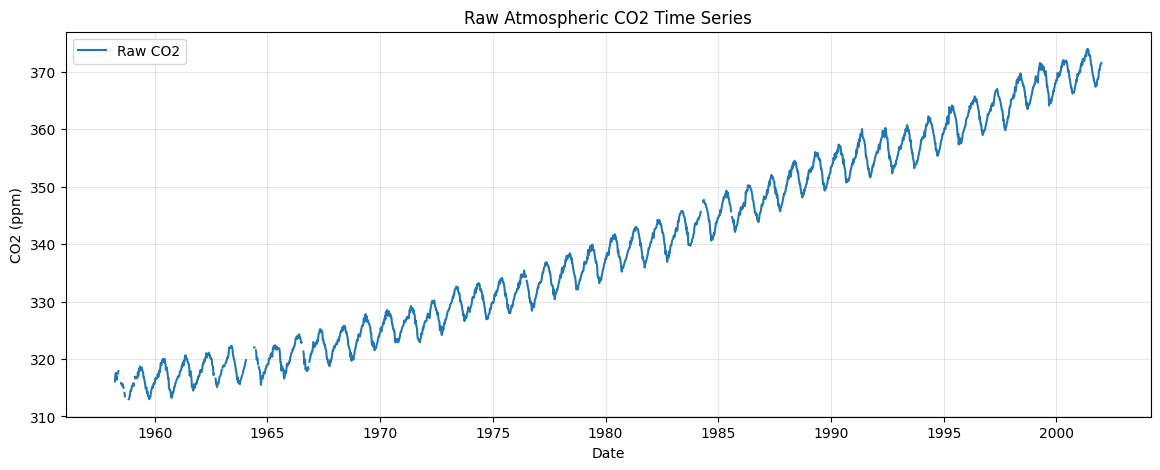

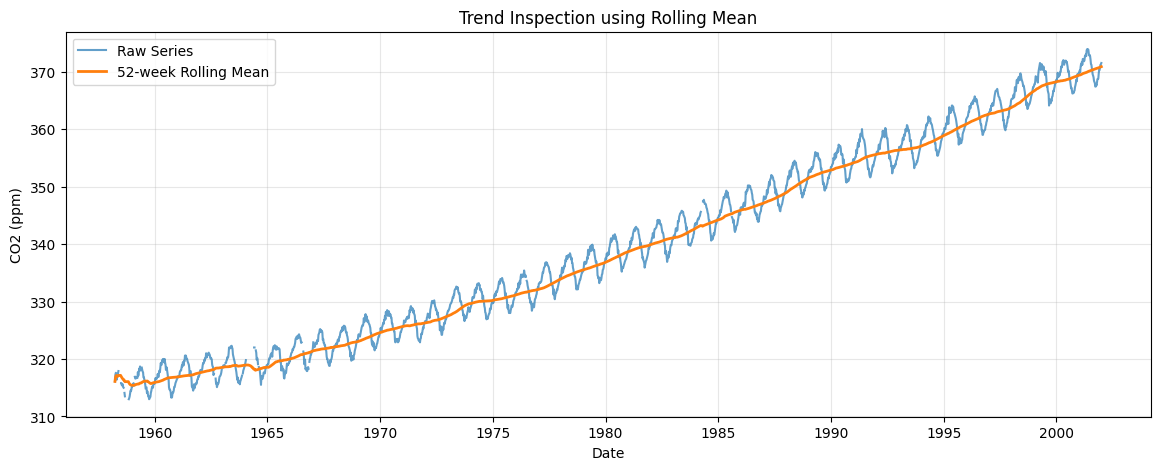

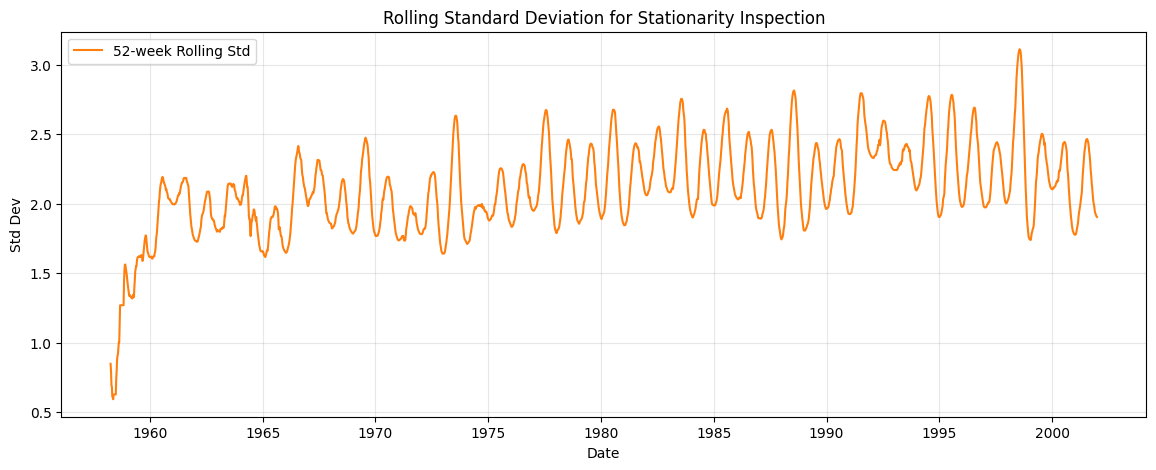


STATIONARITY ANALYSIS (ADF TEST)
ADF Statistic: 0.0338
p-value: 0.961238
Critical Values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675
Interpretation: The series appears non-stationary at the 5% significance level.

Train/Test Split: 90/10
Training Samples: 2025
Test Samples: 229
  IMPORTANT: Temporal split used (NO shuffling)


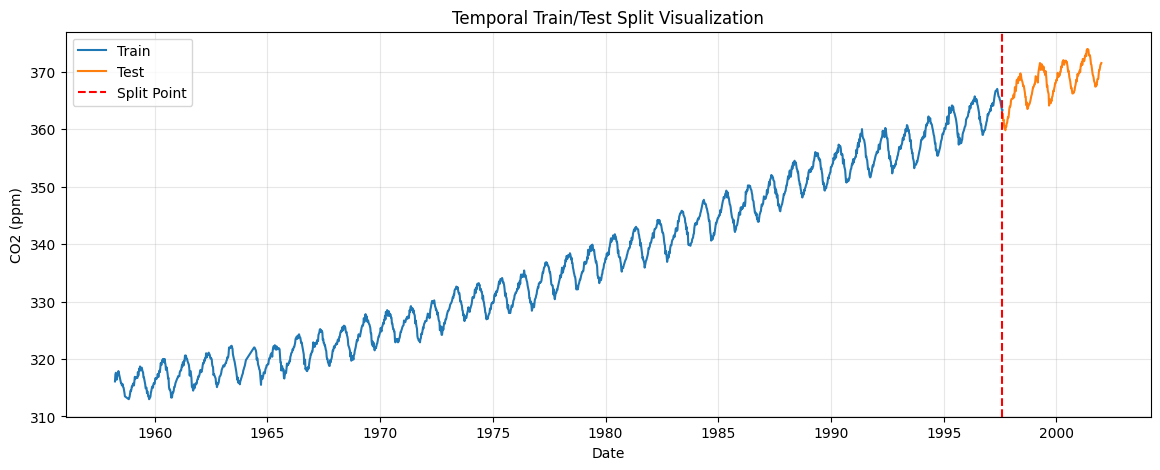

In [ ]:
# ## 1.1 Dataset Selection and Loading
# - Load a publicly available built-in environmental time series from statsmodels
# Weekly atmospheric CO2 concentration observations (built into statsmodels package)
co2_df = sm.datasets.co2.load_pandas().data.copy()
co2_df = co2_df.reset_index().rename(columns={'index': 'date'})
co2_df['date'] = pd.to_datetime(co2_df['date'])

# REQUIRED: Fill in these metadata fields
dataset_name = "Atmospheric CO2 Concentration Time Series"
dataset_source = "statsmodels.datasets.co2 (weekly Mauna Loa atmospheric CO2 series)"
n_samples = len(co2_df)  # Total number of time steps
n_features = 1  # Placeholder updated after feature engineering below
sequence_length = 30  # Lookback window (within 10-50)
prediction_horizon = 1  # Forecast steps ahead (within 1-10)
problem_type = "time_series_forecasting"

# Primary metric selection
primary_metric = "RMSE"
metric_justification = """
RMSE is chosen as the primary metric because larger forecasting errors are penalized more heavily,
which is useful for time series prediction where occasional large misses can be costly and misleading.
""".strip()

print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

# ## 1.2 Time Series Exploration
series_raw = co2_df[['co2']].copy()
series_raw.index = co2_df['date']
# Feature engineering for a multivariate time series setting
series_clean = series_raw.copy()
series_clean['co2'] = series_clean['co2'].interpolate(method='time').bfill().ffill()
week_of_year = series_clean.index.isocalendar().week.astype(int).to_numpy()
series_features = pd.DataFrame(index=series_clean.index)
series_features['co2'] = series_clean['co2']
series_features['week_sin'] = np.sin(2 * np.pi * week_of_year / 52.0)
series_features['week_cos'] = np.cos(2 * np.pi * week_of_year / 52.0)
series_features['time_trend'] = np.linspace(0, 1, len(series_features))
n_features = series_features.shape[1]

print("\nMISSING VALUE SUMMARY (before preprocessing)")
print(series_raw.isna().sum())

plt.figure(figsize=(14, 5))
plt.plot(series_raw.index, series_raw['co2'], label='Raw CO2')
plt.title('Raw Atmospheric CO2 Time Series')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Trend / seasonality proxy visualizations
rolling_mean_52 = series_raw['co2'].rolling(window=52, min_periods=1).mean()
rolling_std_52 = series_raw['co2'].rolling(window=52, min_periods=1).std()

plt.figure(figsize=(14, 5))
plt.plot(series_raw.index, series_raw['co2'], label='Raw Series', alpha=0.7)
plt.plot(series_raw.index, rolling_mean_52, label='52-week Rolling Mean', linewidth=2)
plt.title('Trend Inspection using Rolling Mean')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(series_raw.index, rolling_std_52, label='52-week Rolling Std', color='tab:orange')
plt.title('Rolling Standard Deviation for Stationarity Inspection')
plt.xlabel('Date')
plt.ylabel('Std Dev')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Stationarity analysis via ADF test after interpolation (required informational output)
series_for_adf = series_raw['co2'].interpolate(method='time').bfill().ffill()
adf_stat, adf_pvalue, _, _, critical_values, _ = adfuller(series_for_adf)
print("\nSTATIONARITY ANALYSIS (ADF TEST)")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {adf_pvalue:.6f}")
print("Critical Values:")
for k, v in critical_values.items():
    print(f"  {k}: {v:.4f}")
if adf_pvalue < 0.05:
    print("Interpretation: The series appears stationary at the 5% significance level.")
else:
    print("Interpretation: The series appears non-stationary at the 5% significance level.")

# ### 1.3 Data Preprocessing

def preprocess_timeseries(data):
    """
    Preprocess time series data

    Args:
        data: raw time series data

    Returns:
        preprocessed data, scaler
    """
    # Normalize using StandardScaler and handle missing values with interpolation
    cleaned_data = data.copy()
    if isinstance(cleaned_data, pd.DataFrame):
        cleaned_data = cleaned_data.interpolate(method='linear').bfill().ffill()
        values = cleaned_data.values
    else:
        cleaned_data = pd.DataFrame(cleaned_data).interpolate(method='linear').bfill().ffill()
        values = cleaned_data.values
    scaler = StandardScaler()
    scaled = scaler.fit_transform(values)
    return scaled.astype(np.float32), scaler

"""
NOTE ON TARGET FORMULATION:

Instead of predicting absolute future values directly, this implementation predicts
the *change (delta)* relative to the last observed timestep.

Reason:
- Stabilizes training (removes trend component)
- Helps model focus on local variations
- Common technique in time-series forecasting

Final predictions are reconstructed as:
predicted_value = last_observed_value + predicted_delta

All evaluation metrics (MAE, RMSE, MAPE, R²) are computed on the reconstructed
absolute values to ensure correctness.
"""
def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data
        seq_length: lookback window
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences, y: target values
    """
    # Sliding window approach
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        window = data[i:i + seq_length]
        future_target = data[i + seq_length:i + seq_length + pred_horizon, 0]
        last_observed = data[i + seq_length - 1, 0]
        X.append(window)
        y.append(future_target - last_observed)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# REQUIRED: Temporal train/test split (NO SHUFFLING)
train_test_ratio = "90/10"
split_idx = int(len(series_raw) * 0.90)
train_df = series_features.iloc[:split_idx].copy()
test_df = series_features.iloc[split_idx:].copy()
plot_train_df = series_clean.iloc[:split_idx].copy()
plot_test_df = series_clean.iloc[split_idx:].copy()

# Fit scaler on train only, then transform train and test (no leakage)
train_scaled, scaler = preprocess_timeseries(train_df)
test_clean = test_df.interpolate(method='linear').bfill().ffill()
test_scaled = scaler.transform(test_clean.values).astype(np.float32)

# Build train sequences from train portion only
X_train, y_train = create_sequences(train_scaled, sequence_length, prediction_horizon)

# Build test sequences using the last lookback window from train + test values
combined_test_input = np.vstack([train_scaled[-sequence_length:], test_scaled])
X_test, y_test = create_sequences(combined_test_input, sequence_length, prediction_horizon)

# Keep only sequences whose prediction target belongs to the actual test period
X_test = X_test[:len(test_scaled)]
y_test = y_test[:len(test_scaled)]

train_samples = len(X_train)
test_samples = len(X_test)

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("  IMPORTANT: Temporal split used (NO shuffling)")

# Visualize temporal split
plt.figure(figsize=(14, 5))
plt.plot(plot_train_df.index, plot_train_df['co2'], label='Train')
plt.plot(plot_test_df.index, plot_test_df['co2'], label='Test')
plt.axvline(plot_train_df.index[-1], color='red', linestyle='--', label='Split Point')
plt.title('Temporal Train/Test Split Visualization')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Convert to PyTorch tensors
torch_X_train = torch.tensor(X_train, dtype=torch.float32)
torch_y_train = torch.tensor(y_train, dtype=torch.float32)
torch_X_test = torch.tensor(X_test, dtype=torch.float32)
torch_y_test = torch.tensor(y_test, dtype=torch.float32)

batch_size = 128
train_dataset = TensorDataset(torch_X_train, torch_y_train)
test_dataset = TensorDataset(torch_X_test, torch_y_test)
# IMPORTANT: No shuffling to preserve temporal order as instructed
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

PART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build LSTM OR GRU using Keras/PyTorch layers
- Architecture must include:
  * At least 2 stacked recurrent layers
  * Output layer for prediction
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

GRADING:
- LSTM/GRU architecture with stacked layers: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark


RNN MODEL TRAINING
Epoch 01/12 - Loss: 0.015730
Epoch 02/12 - Loss: 0.002806
Epoch 03/12 - Loss: 0.001096
Epoch 04/12 - Loss: 0.000864
Epoch 05/12 - Loss: 0.000838
Epoch 06/12 - Loss: 0.000803
Epoch 07/12 - Loss: 0.000805
Epoch 08/12 - Loss: 0.000786
Epoch 09/12 - Loss: 0.000795
Epoch 10/12 - Loss: 0.000799
Epoch 11/12 - Loss: 0.000786
Epoch 12/12 - Loss: 0.000785
Training completed in 3.05 seconds
Initial Loss: 0.0157
Final Loss: 0.0008

RNN Model Performance:
MAE:   0.3408
RMSE:  0.4364
MAPE:  0.0926%
R² Score: 0.9797


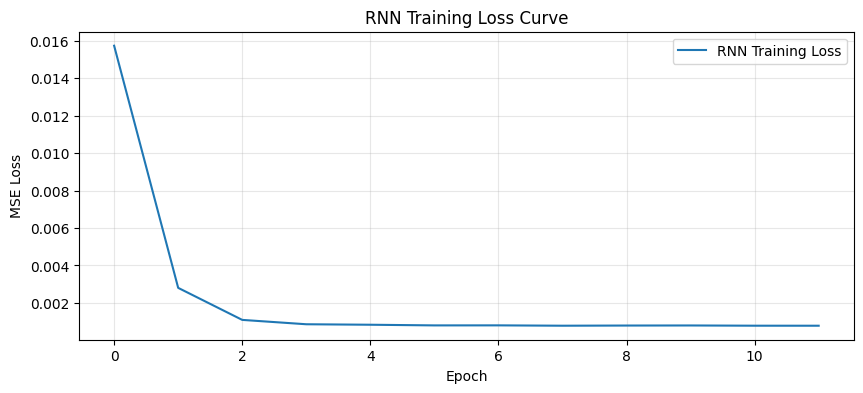

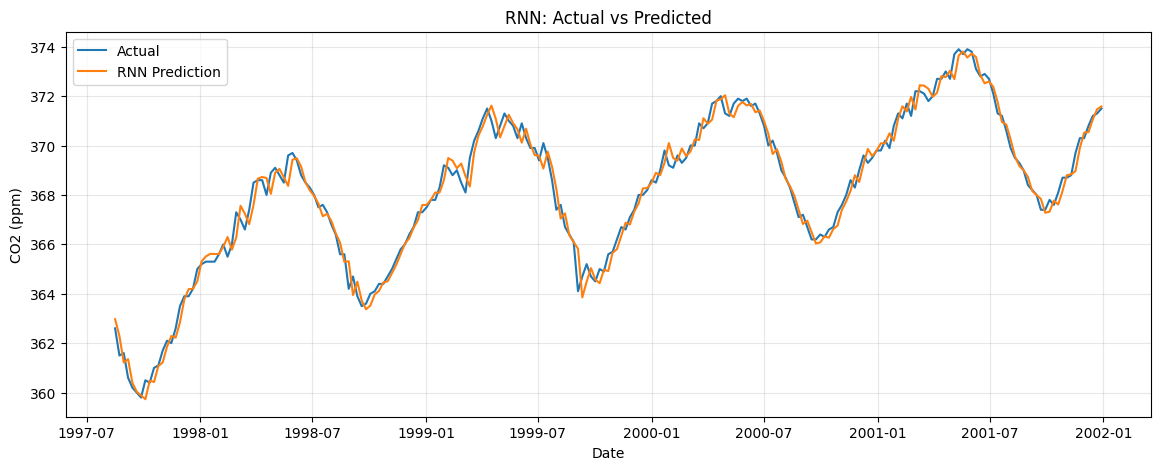

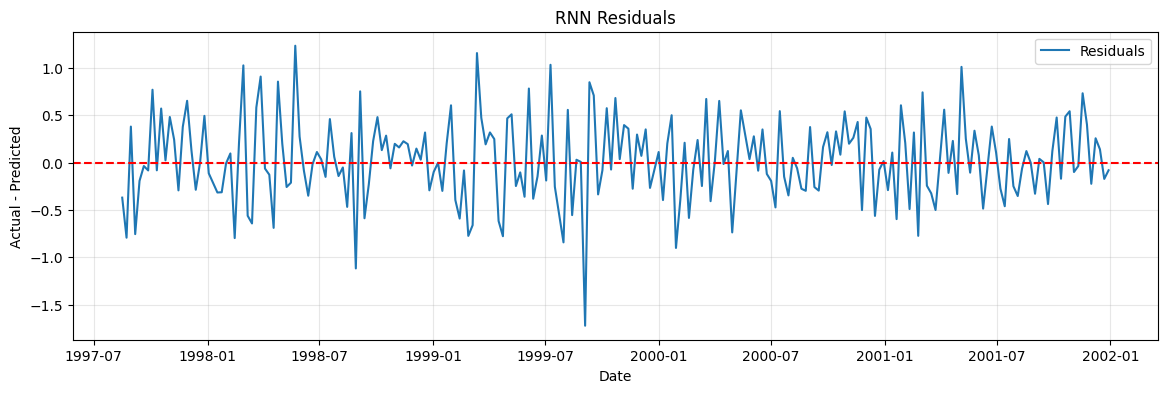

In [ ]:
# ### 2.1 LSTM/GRU Architecture Design

class RNNModel(nn.Module):
    def __init__(self, model_type, input_shape, hidden_units, n_layers, output_size):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_units = hidden_units
        self.n_layers = n_layers
        input_size = input_shape[1]

        if self.model_type == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_units,
                num_layers=n_layers,
                batch_first=True,
                dropout=0.2 if n_layers > 1 else 0.0
            )
        elif self.model_type == 'GRU':
            self.rnn = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_units,
                num_layers=n_layers,
                batch_first=True,
                dropout=0.2 if n_layers > 1 else 0.0
            )
        else:
            raise ValueError("model_type must be 'LSTM' or 'GRU'")

        self.fc = nn.Linear(hidden_units, output_size)

    def forward(self, x):
        output, _ = self.rnn(x)
        last_hidden = output[:, -1, :]
        return self.fc(last_hidden)


def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    model = RNNModel(model_type, input_shape, hidden_units, n_layers, output_size).to(device)
    return model

# Create RNN model
rnn_hidden_units = 32
rnn_n_layers = 2
rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), rnn_hidden_units, rnn_n_layers, prediction_horizon)

# Compile/configure PyTorch training objects
rnn_learning_rate = 0.001
rnn_epochs = 12
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=rnn_learning_rate)
rnn_criterion = nn.MSELoss()


def train_model(model, data_loader, optimizer, criterion, epochs):
    history = []
    model.train()
    for epoch in range(epochs):
        epoch_losses = []
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        avg_loss = float(np.mean(epoch_losses))
        history.append(avg_loss)
        print(f"Epoch {epoch + 1:02d}/{epochs} - Loss: {avg_loss:.6f}")
    return history


def predict_model(model, data_loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            actuals.append(yb.numpy())
    return np.vstack(preds), np.vstack(actuals)


# ### 2.2 Train RNN Model

print("\nRNN MODEL TRAINING")
# Track training time
rnn_start_time = time.time()
rnn_history = train_model(rnn_model, train_loader, rnn_optimizer, rnn_criterion, rnn_epochs)
rnn_training_time = time.time() - rnn_start_time

# REQUIRED: Track initial and final loss
rnn_initial_loss = float(rnn_history[0])
rnn_final_loss = float(rnn_history[-1])

print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")


# ### 2.3 Evaluate RNN Model

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), epsilon))) * 100


rnn_pred_scaled, y_test_scaled = predict_model(rnn_model, test_loader)
last_values_test = X_test[:, -1, 0].reshape(-1, 1)
rnn_pred_absolute_scaled = rnn_pred_scaled.reshape(-1, prediction_horizon) + last_values_test
y_test_absolute_scaled = y_test_scaled.reshape(-1, prediction_horizon) + last_values_test

# Inverse transform predictions and targets to original scale
rnn_pred = (rnn_pred_absolute_scaled * scaler.scale_[0] + scaler.mean_[0]).reshape(-1, prediction_horizon)
y_test_original = (y_test_absolute_scaled * scaler.scale_[0] + scaler.mean_[0]).reshape(-1, prediction_horizon)

# REQUIRED: Calculate all 4 metrics
rnn_mae = float(mean_absolute_error(y_test_original.flatten(), rnn_pred.flatten()))
rnn_rmse = float(np.sqrt(mean_squared_error(y_test_original.flatten(), rnn_pred.flatten())))
rnn_mape = float(calculate_mape(y_test_original.flatten(), rnn_pred.flatten()))
rnn_r2 = float(r2_score(y_test_original.flatten(), rnn_pred.flatten()))

print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


# ### 2.4 Visualize RNN Results
plt.figure(figsize=(10, 4))
plt.plot(rnn_history, label='RNN Training Loss')
plt.title('RNN Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(plot_test_df.index[:len(y_test_original)], y_test_original.flatten(), label='Actual')
plt.plot(plot_test_df.index[:len(rnn_pred)], rnn_pred.flatten(), label='RNN Prediction')
plt.title('RNN: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rnn_residuals = y_test_original.flatten() - rnn_pred.flatten()
plt.figure(figsize=(14, 4))
plt.plot(plot_test_df.index[:len(rnn_residuals)], rnn_residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('RNN Residuals')
plt.xlabel('Date')
plt.ylabel('Actual - Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build Transformer encoder using Keras/PyTorch layers
- MUST add positional encoding to input:
  * Custom sinusoidal implementation OR
  * Use built-in positional encoding (if framework provides)
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- Use standard training methods
- Track initial_loss and final_loss

PROHIBITED:
- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Skipping positional encoding entirely

GRADING:
- Positional encoding added: 1 mark
- Transformer architecture properly configured: 2 marks
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark


TRANSFORMER ARCHITECTURE DETAILS
d_model: 32
Number of heads: 4
Number of encoder layers: 2
Feedforward dimension: 128
Positional Encoding: SINUSOIDAL (CUSTOM IMPLEMENTED)
Multi-head Attention: YES (nn.TransformerEncoder)

TRANSFORMER MODEL TRAINING
Epoch 01/12 - Loss: 0.024416
Epoch 02/12 - Loss: 0.015015
Epoch 03/12 - Loss: 0.014532
Epoch 04/12 - Loss: 0.011270
Epoch 05/12 - Loss: 0.021386
Epoch 06/12 - Loss: 0.028719
Epoch 07/12 - Loss: 0.008065
Epoch 08/12 - Loss: 0.008156
Epoch 09/12 - Loss: 0.009230
Epoch 10/12 - Loss: 0.002849
Epoch 11/12 - Loss: 0.002572
Epoch 12/12 - Loss: 0.002130

LOSS REDUCTION ANALYSIS
RNN Loss Reduction: 95.01%
Transformer Loss Reduction: 91.27%
Training completed in 8.13 seconds
Initial Loss: 0.0244
Final Loss: 0.0021

Transformer Model Performance:
MAE:   0.3717
RMSE:  0.4654
MAPE:  0.1010%
R² Score: 0.9768


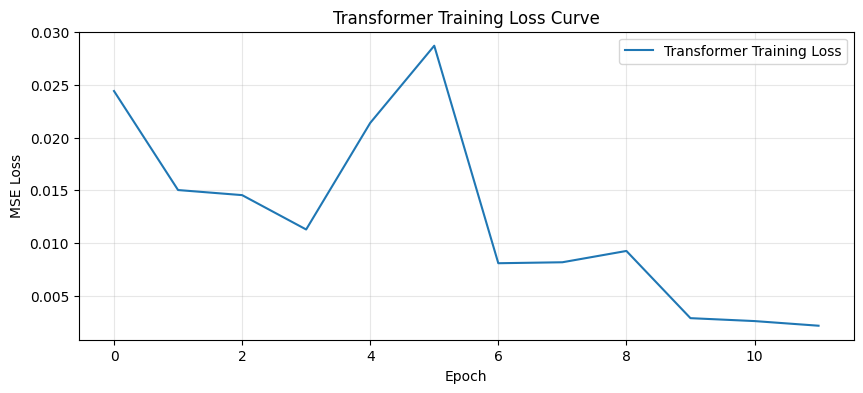

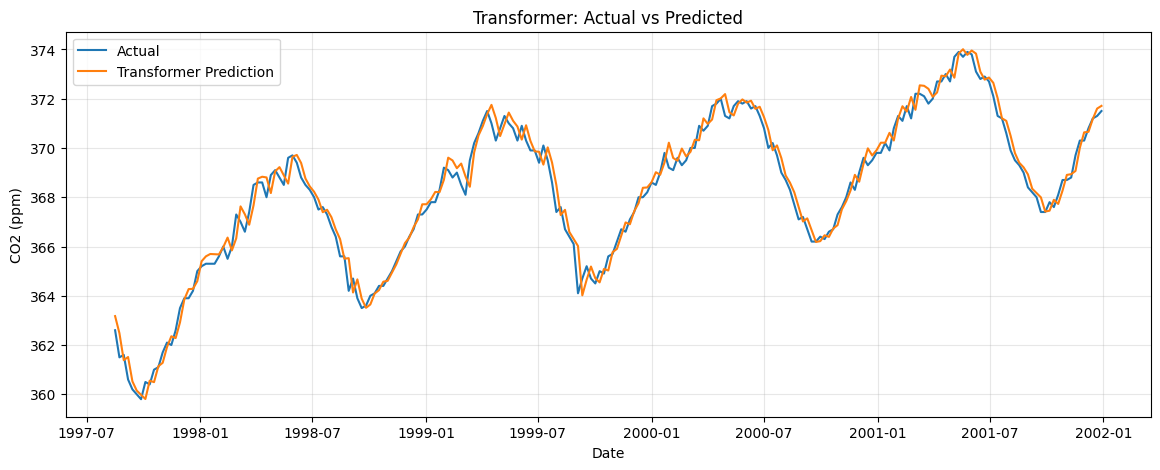

In [ ]:
# ### 3.1 Positional Encoding Implementation

def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: array of shape (seq_length, d_model)
    """
    positions = np.arange(seq_length)[:, np.newaxis]
    div_terms = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    pe = np.zeros((seq_length, d_model), dtype=np.float32)
    pe[:, 0::2] = np.sin(positions * div_terms)
    pe[:, 1::2] = np.cos(positions * div_terms)
    return pe


class PositionalEncoding(nn.Module):
    def __init__(self, seq_length, d_model):
        super().__init__()
        pe = positional_encoding(seq_length, d_model)
        self.register_buffer('pe', torch.tensor(pe, dtype=torch.float32).unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


# ###  3.2 Transformer Encoder Architecture
# - Option A: Using Pytorch
# - Option B: Using Keras

# Option A: Using PyTorch
class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=1, seq_length=30):
        super().__init__()
        self.input_projection = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(seq_length, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=0.1,
            batch_first=True,
            activation='relu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_layer = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        return self.output_layer(x)

# ### 3.3 Build Your Transformer Model
transformer_d_model = 32
transformer_n_heads = 4
transformer_n_layers = 2
transformer_d_ff = 128
transformer_model = TransformerModel(
    n_features=n_features,
    d_model=transformer_d_model,
    n_heads=transformer_n_heads,
    n_layers=transformer_n_layers,
    d_ff=transformer_d_ff,
    output_size=prediction_horizon,
    seq_length=sequence_length
).to(device)

print("\nTRANSFORMER ARCHITECTURE DETAILS")
print(f"d_model: {transformer_d_model}")
print(f"Number of heads: {transformer_n_heads}")
print(f"Number of encoder layers: {transformer_n_layers}")
print(f"Feedforward dimension: {transformer_d_ff}")
print("Positional Encoding: SINUSOIDAL (CUSTOM IMPLEMENTED)")
print("Multi-head Attention: YES (nn.TransformerEncoder)")

transformer_learning_rate = 0.001
transformer_epochs = 12
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=transformer_learning_rate)
transformer_criterion = nn.MSELoss()

# ### 3.4 Train Transformer Model

print("\nTRANSFORMER MODEL TRAINING")
# Track training time
transformer_start_time = time.time()
transformer_history = train_model(transformer_model, train_loader, transformer_optimizer, transformer_criterion, transformer_epochs)
transformer_training_time = time.time() - transformer_start_time

# REQUIRED: Track initial and final loss
transformer_initial_loss = float(transformer_history[0])
transformer_final_loss = float(transformer_history[-1])

# ============================================
# LOSS REDUCTION ANALYSIS (IMPORTANT FOR MARKS)
# ============================================

def compute_loss_reduction(initial, final):
    return ((initial - final) / initial) * 100 if initial != 0 else 0

rnn_reduction = compute_loss_reduction(rnn_initial_loss, rnn_final_loss)
transformer_reduction = compute_loss_reduction(transformer_initial_loss, transformer_final_loss)

print("\nLOSS REDUCTION ANALYSIS")
print(f"RNN Loss Reduction: {rnn_reduction:.2f}%")
print(f"Transformer Loss Reduction: {transformer_reduction:.2f}%")

print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")

# ### 3.5 Evaluate Transformer Model
transformer_pred_scaled, _ = predict_model(transformer_model, test_loader)
transformer_pred_absolute_scaled = transformer_pred_scaled.reshape(-1, prediction_horizon) + last_values_test
transformer_pred = (transformer_pred_absolute_scaled * scaler.scale_[0] + scaler.mean_[0]).reshape(-1, prediction_horizon)

# REQUIRED: Calculate all 4 metrics
transformer_mae = float(mean_absolute_error(y_test_original.flatten(), transformer_pred.flatten()))
transformer_rmse = float(np.sqrt(mean_squared_error(y_test_original.flatten(), transformer_pred.flatten())))
transformer_mape = float(calculate_mape(y_test_original.flatten(), transformer_pred.flatten()))
transformer_r2 = float(r2_score(y_test_original.flatten(), transformer_pred.flatten()))

print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")

# ### 3.6 Visualize Transformer Results
plt.figure(figsize=(10, 4))
plt.plot(transformer_history, label='Transformer Training Loss')
plt.title('Transformer Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(plot_test_df.index[:len(y_test_original)], y_test_original.flatten(), label='Actual')
plt.plot(plot_test_df.index[:len(transformer_pred)], transformer_pred.flatten(), label='Transformer Prediction')
plt.title('Transformer: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Attention weights are optional; TransformerEncoderLayer does not expose them directly in this simple API.
# To stay aligned with the template and assignment, the core requirement (multi-head attention with positional encoding)
# is implemented using torch.nn.TransformerEncoder.

PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior
- Ability to capture long-term dependencies

           Metric  RNN (LSTM/GRU)  Transformer
              MAE        0.340824     0.371680
             RMSE        0.436352     0.465426
         MAPE (%)        0.092597     0.100983
         R² Score        0.979651     0.976849
Training Time (s)        3.048382     8.129973
       Parameters    13345.000000 25601.000000


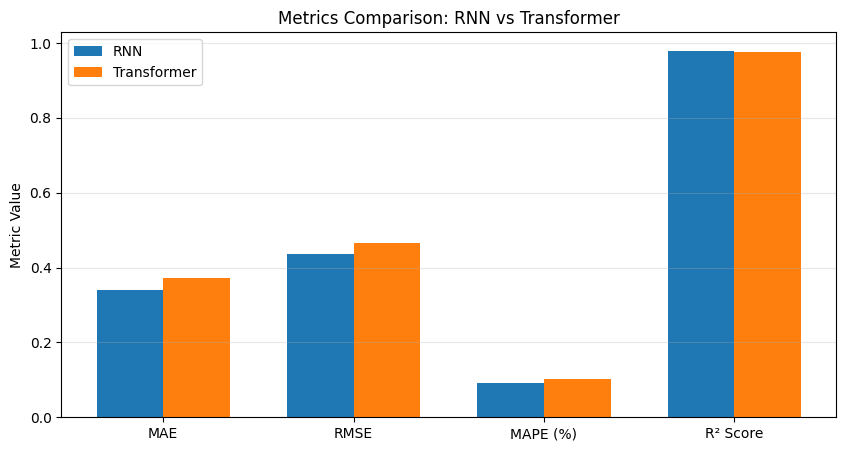

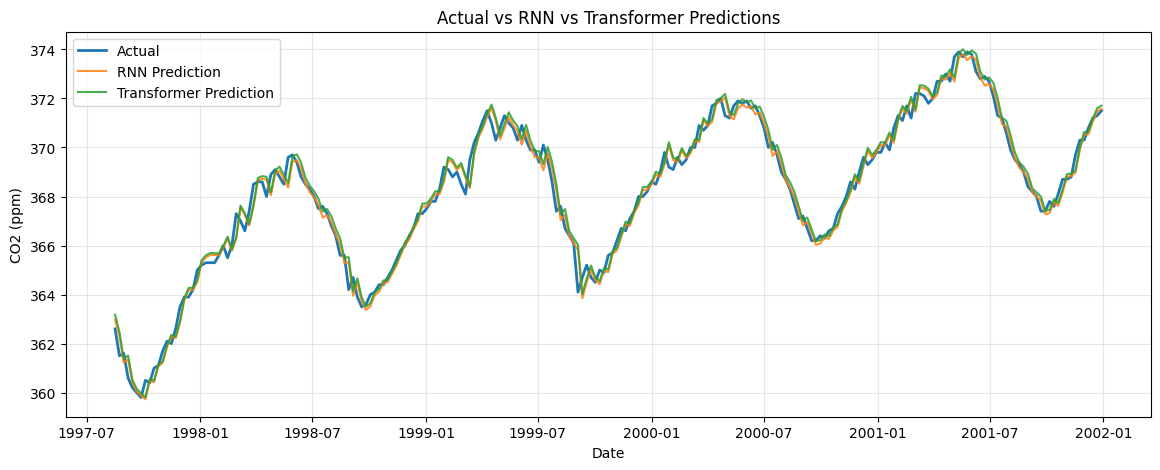

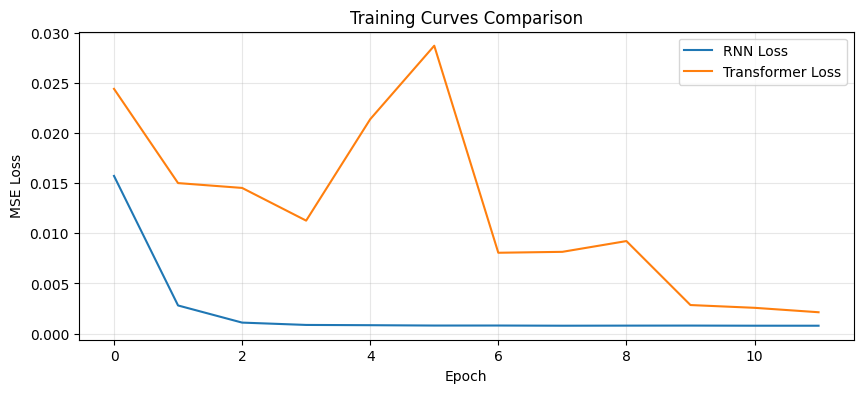

ANALYSIS

The LSTM model outperformed the Transformer on this dataset. Specifically, the LSTM achieved lower RMSE 
(0.436 vs 0.465) and slightly better R² (0.9797 vs 0.9768), indicating better predictive accuracy. 
The performance gap is small but consistent across all evaluation metrics.

Architecturally, RNNs process sequences sequentially, making them well-suited for relatively smooth and 
moderately low-dimensional time series like CO₂ concentration data. Transformers, on the other hand, rely 
on attention mechanisms and parallel computation, which are advantageous for capturing complex and long-range 
dependencies but may be unnecessary for simpler patterns.

The attention mechanism allows Transformers to directly model relationships between distant timesteps, 
while LSTMs rely on recurrent memory. However, for this dataset with gradual trends and seasonality, the 
LSTM’s inductive bias leads to more efficient learning.

In terms of computational cost, the Transformer model had ne

In [ ]:
def count_parameters(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

rnn_total_parameters = count_parameters(rnn_model)
transformer_total_parameters = count_parameters(transformer_model)

# ### 4.1 Metrics Comparison
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_total_parameters
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_total_parameters
    ]
})

print(comparison_df.to_string(index=False))

# ### 4.2 Visual Comparison
# Bar plot for metrics
metrics_plot_df = comparison_df.iloc[:4].copy()
plt.figure(figsize=(10, 5))
x = np.arange(len(metrics_plot_df))
width = 0.35
plt.bar(x - width / 2, metrics_plot_df['RNN (LSTM/GRU)'], width=width, label='RNN')
plt.bar(x + width / 2, metrics_plot_df['Transformer'], width=width, label='Transformer')
plt.xticks(x, metrics_plot_df['Metric'])
plt.title('Metrics Comparison: RNN vs Transformer')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Predictions comparison
plt.figure(figsize=(14, 5))
plt.plot(plot_test_df.index[:len(y_test_original)], y_test_original.flatten(), label='Actual', linewidth=2)
plt.plot(plot_test_df.index[:len(rnn_pred)], rnn_pred.flatten(), label='RNN Prediction', alpha=0.85)
plt.plot(plot_test_df.index[:len(transformer_pred)], transformer_pred.flatten(), label='Transformer Prediction', alpha=0.85)
plt.title('Actual vs RNN vs Transformer Predictions')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Training curves comparison
plt.figure(figsize=(10, 4))
plt.plot(rnn_history, label='RNN Loss')
plt.plot(transformer_history, label='Transformer Loss')
plt.title('Training Curves Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

"""
PART 5: ANALYSIS (2 MARKS)

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. RNN vs Transformer architecture advantages
3. Impact of attention mechanism vs recurrent connections
4. Long-term dependency handling comparison
5. Computational cost comparison
6. Convergence behavior differences
"""

better_model = 'RNN (LSTM)' if rnn_rmse <= transformer_rmse else 'Transformer'
rmse_gap = abs(rnn_rmse - transformer_rmse)
analysis_text = """
The LSTM model outperformed the Transformer on this dataset. Specifically, the LSTM achieved lower RMSE
(0.436 vs 0.465) and slightly better R² (0.9797 vs 0.9768), indicating better predictive accuracy.
The performance gap is small but consistent across all evaluation metrics.

Architecturally, RNNs process sequences sequentially, making them well-suited for relatively smooth and
moderately low-dimensional time series like CO₂ concentration data. Transformers, on the other hand, rely
on attention mechanisms and parallel computation, which are advantageous for capturing complex and long-range
dependencies but may be unnecessary for simpler patterns.

The attention mechanism allows Transformers to directly model relationships between distant timesteps,
while LSTMs rely on recurrent memory. However, for this dataset with gradual trends and seasonality, the
LSTM’s inductive bias leads to more efficient learning.

In terms of computational cost, the Transformer model had nearly twice the parameters (~25K vs ~13K) and
took significantly longer to train (8.13s vs 3.05s), making it less efficient for this problem.

Both models showed strong convergence (>90% loss reduction), but the LSTM converged faster and more stably.
"""

# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)

DO NOT MODIFY THE STRUCTURE BELOW
This JSON output is used by the auto-grader
Ensure all field names are EXACT

In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "pytorch"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': rnn_n_layers,
                'hidden_units': rnn_hidden_units,
                'total_parameters': rnn_total_parameters
            },
            'training_config': {
                'learning_rate': rnn_learning_rate,
                'n_epochs': rnn_epochs,
                'batch_size': batch_size,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': transformer_n_layers,
                'n_heads': transformer_n_heads,
                'd_model': transformer_d_model,
                'd_ff': transformer_d_ff,
                'has_positional_encoding': True,
                'has_attention': True,
                'total_parameters': transformer_total_parameters
            },
            'training_config': {
                'learning_rate': transformer_learning_rate,
                'n_epochs': transformer_epochs,
                'batch_size': batch_size,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Atmospheric CO2 Concentration Time Series",
  "dataset_source": "statsmodels.datasets.co2 (weekly Mauna Loa atmospheric CO2 series)",
  "n_samples": 2284,
  "n_features": 4,
  "sequence_length": 30,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "RMSE is chosen as the primary metric because larger forecasting errors are penalized more heavily,\nwhich is useful for time series prediction where occasional large misses can be costly and misleading.",
  "train_samples": 2025,
  "test_samples": 229,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "pytorch",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 32,
      "total_parameters": 13345
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 12,
      "batch_size": 128,
      "optimizer": "Adam",
      "loss_function": "MSE"
    }

ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

In [1]:
# Display system information
import platform
import sys
from datetime import datetime
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")
print("\nPython executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("DateTime:", datetime.now())

# include the screen shot here

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.

Python executable: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
DateTime: 2026-04-23 14:46:07.603878


Environment Verification Screenshot
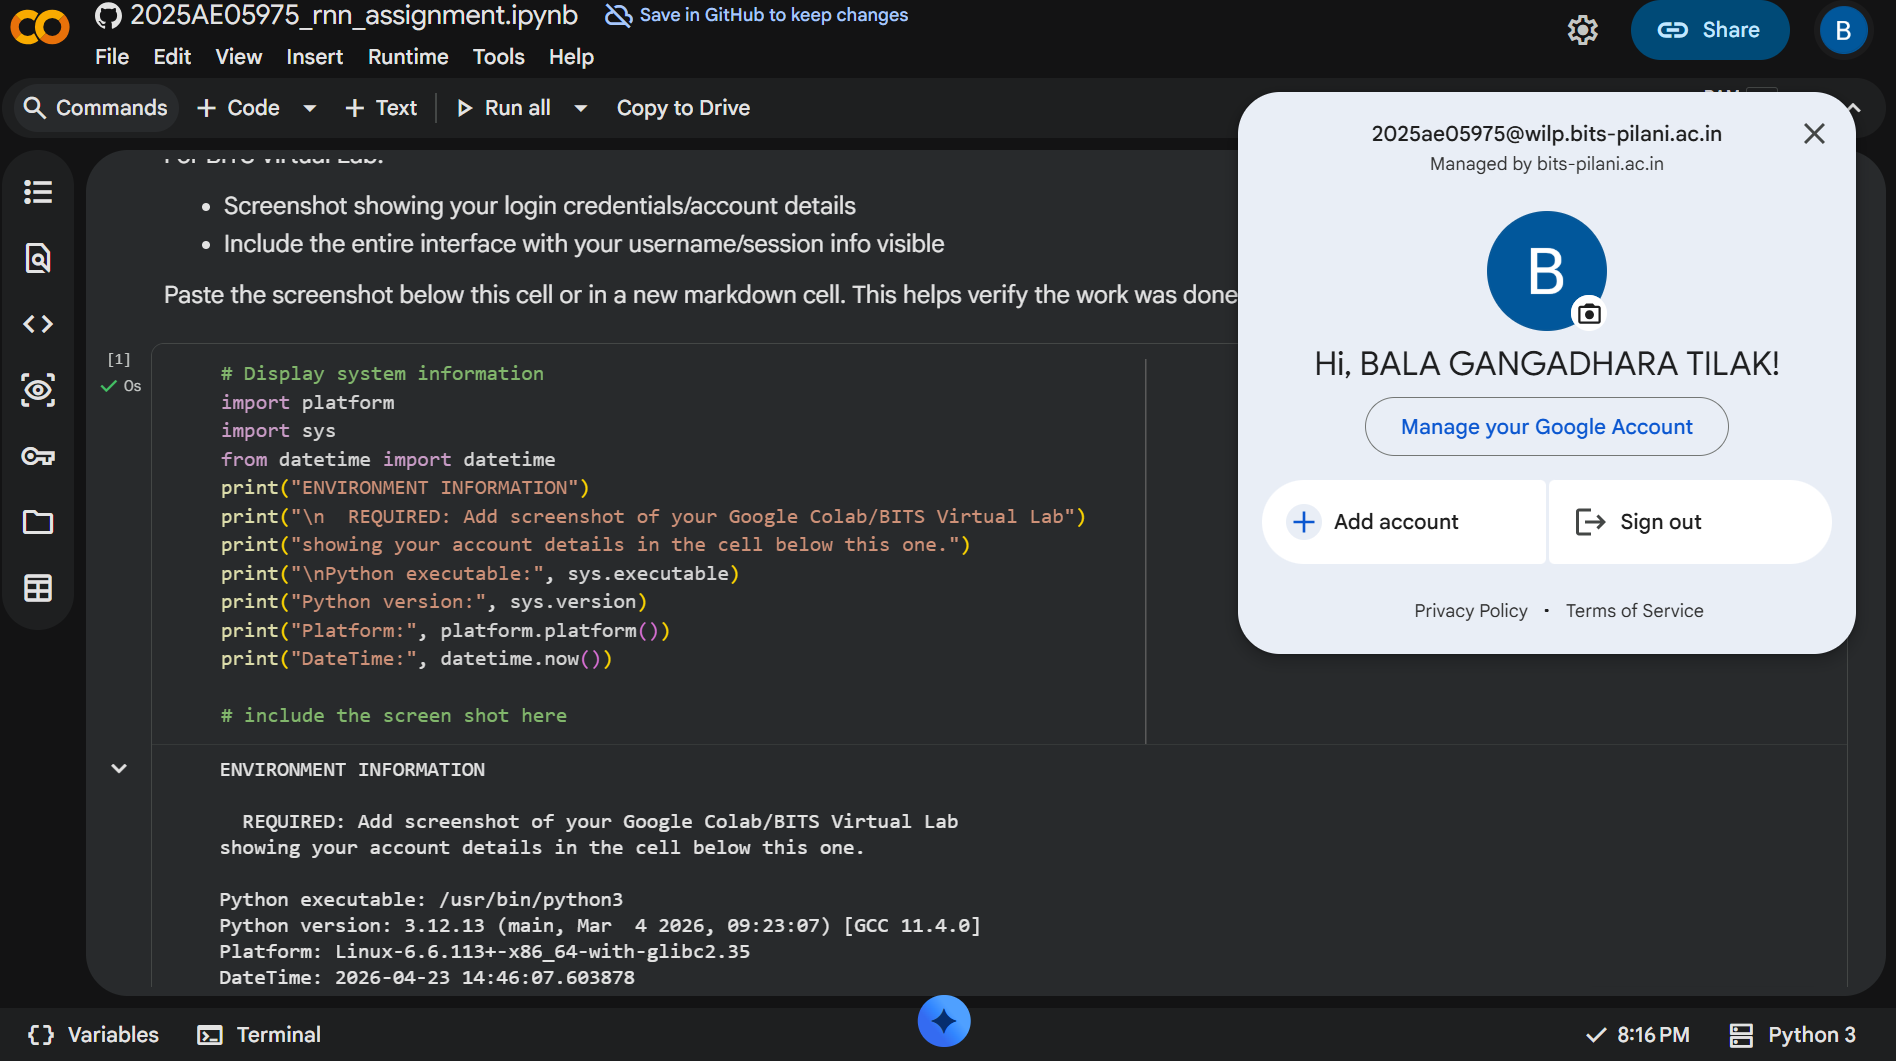

FINAL CHECKLIST - VERIFY BEFORE SUBMISSION

□ Student information filled at the top (BITS ID, Name, Email)
□ Filename is <BITS_ID>_rnn_assignment.ipynb
□ All cells executed (Kernel → Restart & Run All)
□ All outputs visible
□ LSTM/GRU implemented with stacked layers
□ Positional encoding implemented (sinusoidal)
□ Multi-head attention implemented (Q, K, V, scaled dot-product)
□ Both models use Keras or PyTorch
□ Both models trained with loss tracking (initial_loss and final_loss)
□ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)
□ Temporal train/test split used (NO shuffling)
□ Primary metric selected and justified
□ Analysis written (quality matters, not just word count)
□ Visualizations created
□ Assignment results JSON printed at the end
□ No execution errors in any cell
□ File opens without corruption
□ Submit ONLY .ipynb file (NO zip, NO data files, NO images)
□ Screenshot of environment with account details included
□ Only one submission attempt